# Анализ сохранённых параметрических опытов
Здесь нет вызовов симулятора: все показатели считываются из ранее созданных CSV.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiment_support.jl"))

animate_sir

## Источники результатов

In [2]:
replicates = CSV.read(datadir("sir_param_replicates.csv"), DataFrame)
summary = CSV.read(datadir("sir_param_summary.csv"), DataFrame)
deterministic = CSV.read(datadir("sir_param_deterministic.csv"), DataFrame)
scan = CSV.read(datadir("sir_scan_param.csv"), DataFrame)
animation_summary = CSV.read(datadir("sir_animation_param_summary.csv"), DataFrame)
(replicates=nrow(replicates), combinations=nrow(summary), scan_points=nrow(scan),
    animations=nrow(animation_summary))

(replicates = 180, combinations = 9, scan_points = 45, animations = 3)

## Сопоставление средних SSA и непрерывного пика ОДУ

In [3]:
comparison = innerjoin(summary, deterministic[:, [:case_id, :refined_peak]]; on=:case_id)
comparison.difference = comparison.peak_mean .- comparison.refined_peak
save_table("sir_param_comparison.csv", comparison)
comparison

Row,case_id,β,γ,peak_mean,peak_sd,final_R_mean,final_R_sd,time_mean,refined_peak,difference
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,0.1,0.05,996.85,1.87153,993.5,2.39517,0.120284,995.705,1.14543
2,2,0.3,0.05,998.95,0.759155,993.15,3.16685,0.03995,998.385,0.564911
3,3,0.8,0.05,999.6,0.598243,992.8,2.54641,0.0145504,999.333,0.266893
4,4,0.1,0.1,993.35,2.41214,999.95,0.223607,0.108671,992.102,1.2477
5,5,0.3,0.1,997.8,1.36111,999.9,0.307794,0.0412223,997.001,0.798772
6,6,0.8,0.1,999.0,1.1698,999.95,0.223607,0.0155214,998.753,0.247143
7,7,0.1,0.2,985.7,3.21346,1000.0,0.0,0.104662,985.591,0.109116
8,8,0.3,0.2,996.0,1.52177,1000.0,0.0,0.0390938,994.465,1.53545
9,9,0.8,0.2,998.55,1.09904,1000.0,0.0,0.0144826,997.679,0.871


## Пик и конечное число выздоровевших

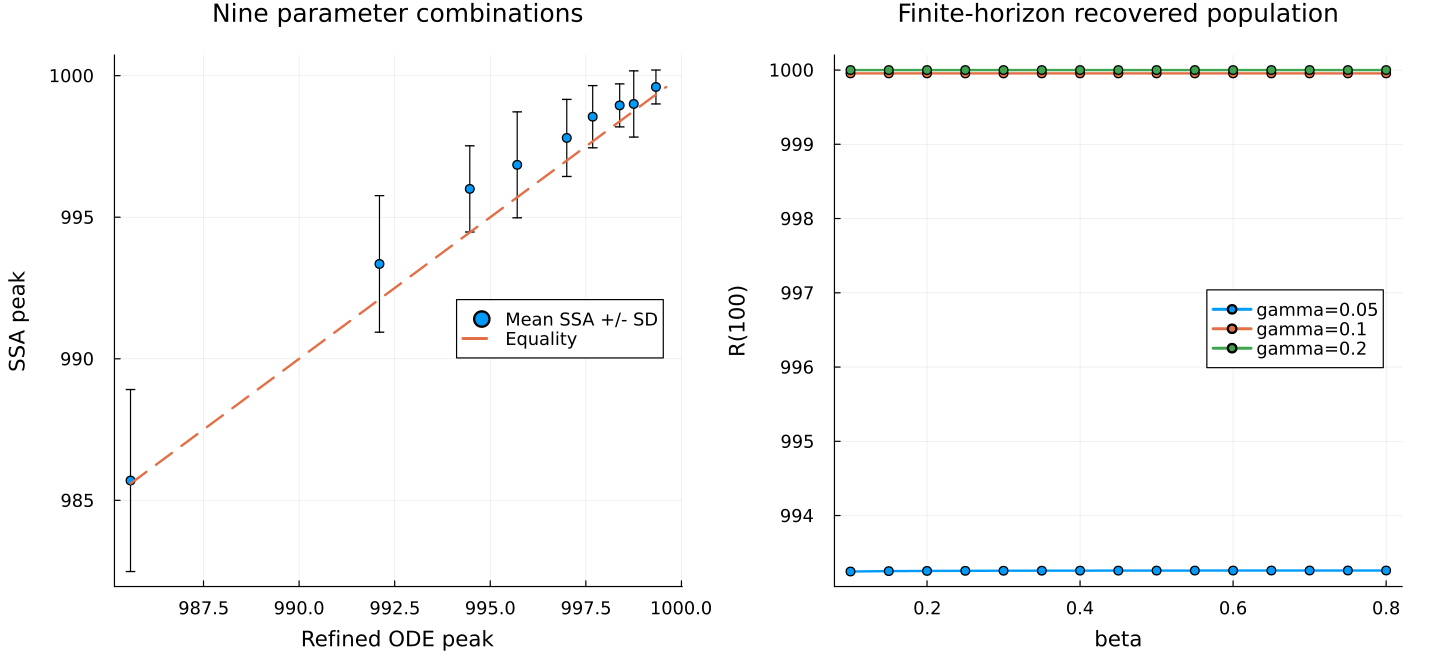

In [4]:
p_peak = plot(comparison.refined_peak, comparison.peak_mean;
    yerror=comparison.peak_sd, seriestype=:scatter, label="Mean SSA +/- SD",
    xlabel="Refined ODE peak", ylabel="SSA peak", title="Nine parameter combinations")
lims = extrema(vcat(comparison.refined_peak, comparison.peak_mean))
plot!(p_peak, collect(lims), collect(lims); label="Equality", linestyle=:dash)
p_final = plot(; xlabel="beta", ylabel="R(100)", title="Finite-horizon recovered population")
for γ in sort(unique(scan.γ))
    d = sort(scan[scan.γ .== γ,:], :β)
    plot!(p_final, d.β, d.final_R; marker=:circle, label="gamma=$(γ)")
end
p = plot(p_peak, p_final; layout=(1,2), size=(1200,550))
savefig(p, imagepath("12-plot.png"))
display(p)

## Показатель воспроизводимости данных

In [5]:
DataFrame(total_SSA_runs=[nrow(replicates)], seeds_unique=[length(unique(replicates.seed))],
    max_conservation_error=[maximum(replicates.conservation_error)],
    total_animation_frames=[sum(animation_summary.frames)])

Row,total_SSA_runs,seeds_unique,max_conservation_error,total_animation_frames
,Int64,Int64,Int64,Int64
1,180,180,0,1503
